In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import cebra
import cebra.datasets
from cebra import CEBRA

import torch.nn as nn
from cebra.data.datatypes import Offset
from sklearn.metrics import mean_squared_error

import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns



# reload the data we dumped in cell 31

base = "./outputs/glm_input_data/"

beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
beh_idx = np.load(os.path.join(base, "behavior_glm_input_index.npy"),
                  allow_pickle=True)
beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"),
                   allow_pickle=True)

spk_vals = np.load(os.path.join(base, "fr_full.npy"))
spk_idx = np.load(os.path.join(base, "fr_full_index.npy"),
                  allow_pickle=True)
spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"),
                   allow_pickle=True)

# fr_vals = np.load(os.path.join(base, "fr_full.npy"))
# fr_idx = np.load(os.path.join(base, "fr_full_index.npy"),
#                  allow_pickle=True)
# fr_cols = np.load(os.path.join(base, "fr_full_columns.npy"),
#                   allow_pickle=True)

# reconstruct indexes (they were saved as arrays of tuples)
try:
    beh_index = pd.MultiIndex.from_tuples(beh_idx,
                                          names=behavior_glm_input.index.names)
except Exception:
    beh_index = pd.Index(beh_idx)

try:
    spk_index = pd.MultiIndex.from_tuples(spk_idx,
                                          names=fr_first7.index.names)
except Exception:
    spk_index = pd.Index(spk_idx)

# try:
#     fr_index = pd.MultiIndex.from_tuples(fr_idx, names=fr.index.names)
# except Exception:
#     fr_index = pd.Index(fr_idx)

# build dataframes
behavior_glm_loaded = pd.DataFrame(beh_vals,
                                   index=beh_index,
                                   columns=beh_cols)
spikes_loaded = pd.DataFrame(spk_vals,
                             index=spk_index,
                             columns=spk_cols)
# fr_full_loaded = pd.DataFrame(fr_vals,
#                               index=fr_index,
#                               columns=fr_cols)

print("behavior_glm_loaded shape", behavior_glm_loaded.shape)
print("spikes_loaded shape", spikes_loaded.shape)
# print("fr_full_loaded shape", fr_full_loaded.shape)

behavior_glm_loaded shape (1333016, 29)
spikes_loaded shape (1333016, 77)


In [2]:
class LSTM(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = torch.nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, output_size),
            # torch.nn.Sigmoid()
        )

    def forward(self, x):
        # accept (seq_len, input_size) or (batch, seq_len, input_size)
        added_batch = False
        if x.dim() == 2:  # (seq_len, input_size) -> (1, seq_len, input_size)
            x = x.unsqueeze(0)
            added_batch = True

        batch = x.size(0)
        h0 = x.new_zeros(1, batch, self.hidden_size)
        c0 = x.new_zeros(1, batch, self.hidden_size)

        lstm_out, (hn, cn) = self.lstm(x, (h0, c0))  # (batch, seq_len, hidden_size)
        out = self.fc(lstm_out)  # (batch, seq_len, output_size)

        if added_batch:
            lstm_out = lstm_out.squeeze(0)  # (seq_len, hidden_size)
            out = out.squeeze(0)            # (seq_len, output_size)

        return lstm_out, out
    
class RNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, output_size),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        # accept (seq_len, input_size) or (batch, seq_len, input_size)
        added_batch = False
        if x.dim() == 2:  # (seq_len, input_size) -> (1, seq_len, input_size)
            x = x.unsqueeze(0)
            added_batch = True

        batch = x.size(0)
        h0 = x.new_zeros(1, batch, self.hidden_size)

        rnn_out, hn = self.rnn(x, h0)  # (batch, seq_len, hidden_size)
        out = self.fc(rnn_out)         # (batch, seq_len, output_size)

        if added_batch:
            rnn_out = rnn_out.squeeze(0)  # (seq_len, hidden_size)
            out = out.squeeze(0)            # (seq_len, output_size)

        return rnn_out, out
    
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_hidden_layers, output_size):
        assert num_hidden_layers >= 1
        super(MLP, self).__init__()
        self.hidden_size = hidden_size
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.ReLU(),
            *([torch.nn.Linear(hidden_size, hidden_size), torch.nn.ReLU()] * (num_hidden_layers - 1)),
            torch.nn.Linear(hidden_size, output_size),
            # torch.nn.Sigmoid()
        )

    def forward(self, x):
        return None, self.fc(x)


In [3]:
behavior_glm_loaded.columns

Index(['frame_raw_500msMedian', 'frame_raw_abs_acc_500msMedian',
       'frame_YawPitch_abs_vel_sum_500msMedian',
       'frame_YawPitch_abs_acc_sum_500msMedian',
       'frame_RawYawPitch_abs_vel_sum_500msMedian',
       'frame_RawYawPitch_abs_acc_sum_500msMedian', 'frame_forward_prop',
       'forward_vs_rotation_corr', 'frame_position', 'head_angle_vel',
       'head_angle', 'movement_energy_smooth5', 'frame_ephys_timestamp',
       'frame_pc_timestamp', 'trial_id', 'cue', 'trial_outcome', 'choice_R1',
       'choice_R2', 'upcoming_choice', 'reward_window', 'cue_visible',
       'lick_detected', 'reward-sound_detected', 'reward-valve-open_detected',
       'track_zone', 'track_zone_int', 'from_ephys_timestamp',
       'to_ephys_timestamp'],
      dtype='object')

In [4]:
behavior_glm_loaded["track_zone"].unique()

array([nan, 'startZone', 'visibleCue', 'nextToCue', 'afterCue',
       'reward1Zone', 'bewteenRewardZones', 'reward2Zone', 'endZone',
       'ITI'], dtype=object)

In [5]:
spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)

In [6]:
spikes_loaded

Unit0001  Unit0002  Unit0003  Unit0004  Unit0005  \
2024-11-14_16-40 0              0         0         0         0         0   
                 1              0         0         0         0         0   
                 2              0         0         0         0         0   
                 3              0         0         0         0         0   
                 4              0         0         0         0         0   
...                           ...       ...       ...       ...       ...   
2025-01-27_13-39 110898         0         0         0         0         0   
                 110899         0         0         0         0         0   
                 110900         0         0         0         0         0   
                 110901         0         0         0         0         0   
                 110902         0         0         0         0         0   

                         Unit0006  Unit0007  Unit0008  Unit0009  Unit0010  \
2024-11-14_16-40 0              0         0         0         0         0   
                 1              0         0         0         0         0   
                 2              0         0         0         0         0   
                 3              0         0         0         0         0   
                 4              0         0         0         0         0   
...                           ...       ...       ...       ...       ...   
2025-01-27_13-39 110898         0         0         0         0         0   
                 110899         0         0         0         0         0   
                 110900         0         0         0         0         0   
                 110901         0         0         0         0         0   
                 110902         0         0         0         0         0   

                         ...  Unit0068  Unit0069  Unit0070  Unit0071  \
2024-11-14_16-40 0       ...         0         0         0         0   
                 1       ...         0         0         0         0   
                 2       ...         0         0         0         0   
                 3       ...         0         0         0         0   
                 4       ...         0         0         0         0   
...                      ...       ...       ...       ...       ...   
2025-01-27_13-39 110898  ...        25         0         0        25   
                 110899  ...        25         0         0        25   
                 110900  ...        25        25         0        25   
                 110901  ...        25         0         0         0   
                 110902  ...         0         0        25         0   

                         Unit0072  Unit0073  Unit0074  Unit0075  Unit0076  \
2024-11-14_16-40 0              0         0         0         0         0   
                 1              0         0         0         0         0   
                 2              0         0         0         0         0   
                 3              0         0         0         0         0   
                 4              0         0         0         0         0   
...                           ...       ...       ...       ...       ...   
2025-01-27_13-39 110898         0         0        50         0         0   
                 110899         0         0         0         0         0   
                 110900         0         0         0         0         0   
                 110901         0         0         0         0         0   
                 110902         0         0         0        25         0   

                         Unit0077  
2024-11-14_16-40 0              0  
                 1              0  
                 2              0  
                 3              0  
                 4              0  
...                           ...  
2025-01-27_13-39 110898         0  
                 110899         0  
                 110900         0  
                 110901  

In [7]:
spikes_unique_trials = set()
for idx in spikes_loaded.index:
    spikes_unique_trials.add(idx[0])

In [8]:
behavior_glm_loaded = behavior_glm_loaded[behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)]

In [9]:
non_nan_rows = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded = spikes_loaded.loc[non_nan_rows]

In [10]:
unique_trials = set()

for idx in behavior_glm_loaded.index:
    unique_trials.add(idx[0])

In [11]:
# Select only numeric columns
behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

In [12]:
session_ids = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
session_ids

Index(['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
       '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
       '2024-11-28_17-41', '2024-11-29_17-21', '2024-12-02_16-09',
       '2024-12-03_16-23', '2024-12-04_18-06', '2024-12-06_16-49',
       '2024-12-09_17-45', '2024-12-10_17-20', '2024-12-11_17-42',
       '2024-12-12_16-13', '2024-12-13_17-10', '2025-01-14_18-08',
       '2025-01-15_17-18', '2025-01-16_17-47', '2025-01-17_16-55',
       '2025-01-21_18-49', '2025-01-22_17-51', '2025-01-23_16-48',
       '2025-01-24_12-24', '2025-01-24_19-37', '2025-01-25_21-29',
       '2025-01-26_21-48', '2025-01-27_13-39'],
      dtype='object')

In [13]:
results = []

action_enc_cols = [
    'frame_raw_500msMedian',                  # forward_velocity
    'frame_raw_abs_acc_500msMedian',          # forward_acceleration
    'frame_YawPitch_abs_vel_sum_500msMedian', # off_rotation_velocity
    'frame_YawPitch_abs_acc_sum_500msMedian', # off_rotation_acceleration
    'head_angle_vel',
    'head_angle',
    'movement_energy_smooth5',                # movement_energy
    'upcoming_choice',
    'reward_window',
    'lick_detected',
]
state_enc_cols = [
    'cue_visible',
    'track_zone',
]

In [14]:
session_dataset_singles = {}

for session_id in session_ids:
    session_mask = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
    beh = behavior_glm_loaded[
        session_mask
    ]

    spikes_session = spikes_loaded[
        session_mask
    ]

    # Convert specified columns in beh to z-scores
    for col in action_enc_cols + state_enc_cols:
        if col in beh.columns:
            beh.loc[:, col] = beh[col].astype(float)
            mean_val = beh[col].mean()
            std_val = beh[col].std() + 1e-8
            if std_val != 0:
                beh.loc[:, col] = (beh[col] - mean_val) / std_val

    # Convert all columns in spikes_session to z-scores
    for col in spikes_session.columns:
        # Convert all columns in spikes_session to z-scores
        spikes_session = spikes_session.astype(float)
    label_stds = []
    for col in spikes_session.columns:
        mean_val = spikes_session[col].mean()
        std_val = spikes_session[col].std() + 1e-8
        label_stds.append(std_val)
        if std_val != 0:
            spikes_session[col] = (spikes_session[col] - mean_val) / std_val

    session_dataset_singles[session_id] = {"data": beh[action_enc_cols + state_enc_cols].values.astype(np.float16), "labels": spikes_session.values.astype(np.float16), "label_stds": label_stds}





In [15]:
# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

input_size = len(action_enc_cols) + len(state_enc_cols)
hidden_size = 64
num_hidden_layers = 2
output_size = 1
num_epochs = 100
learning_rate = 0.001
train_test_split = 0.8

num_sessions = len(session_ids)
num_neurons = session_dataset_singles[session_ids[0]]["labels"].shape[1]

mse_matrix = np.zeros((num_sessions, num_neurons))

for test_idx, test_session in enumerate(session_ids):
    session_data   = session_dataset_singles[test_session]["data"]
    session_labels = session_dataset_singles[test_session]["labels"]
    session_label_stds = session_dataset_singles[test_session]["label_stds"]

    n_samples = len(session_data)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    split_idx = int(n_samples * train_test_split)

    train_idx = indices[:split_idx]
    test_idx_  = indices[split_idx:]

    # move data to GPU once per session, not once per neuron
    train_data  = torch.tensor(session_data[train_idx],   dtype=torch.float32).to(device)
    test_data   = torch.tensor(session_data[test_idx_],   dtype=torch.float32).to(device)
    # keep all labels on CPU — slice per neuron as needed
    train_labels_np = session_labels[train_idx].astype(np.float32)
    test_labels_np  = session_labels[test_idx_].astype(np.float32)

    for neuron_idx in range(num_neurons):
        # single neuron label tensor — small, move to GPU only for training
        train_label = torch.tensor(train_labels_np[:, neuron_idx], dtype=torch.float32).to(device)

        model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            _, outputs = model(train_data)
            loss = criterion(outputs.squeeze(), train_label)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            _, predictions = model(test_data)
            predictions_np = predictions.squeeze().cpu().numpy()

        mse = mean_squared_error(test_labels_np[:, neuron_idx], predictions_np)
        mse_matrix[test_idx, neuron_idx] = mse

        print(f"Session {test_idx+1}/{num_sessions}, Neuron {neuron_idx+1}/{num_neurons}, "
              f"MSE: {mse:.4f} Standard Deviation: {session_label_stds[neuron_idx]}")

        # clean up per-neuron allocations
        del model, optimizer, criterion, train_label, predictions, predictions_np
        torch.cuda.empty_cache()

    # clean up per-session allocations
    del train_data, test_data, train_labels_np, test_labels_np
    torch.cuda.empty_cache()

Using device: cuda
Session 1/29, Neuron 1/77, MSE: 1.0839 Standard Deviation: 6.274097400896827
Session 1/29, Neuron 2/77, MSE: 0.9746 Standard Deviation: 3.5353091172308275
Session 1/29, Neuron 3/77, MSE: 1.1299 Standard Deviation: 2.503710755857345
Session 1/29, Neuron 4/77, MSE: 2.3417 Standard Deviation: 0.6394997193393676
Session 1/29, Neuron 5/77, MSE: 0.8676 Standard Deviation: 3.751832519416257
Session 1/29, Neuron 6/77, MSE: 0.0002 Standard Deviation: 1e-08
Session 1/29, Neuron 7/77, MSE: 2.6118 Standard Deviation: 3.121883233536791
Session 1/29, Neuron 8/77, MSE: 0.0001 Standard Deviation: 1e-08
Session 1/29, Neuron 9/77, MSE: 0.9001 Standard Deviation: 2.6691510872169184
Session 1/29, Neuron 10/77, MSE: 0.9212 Standard Deviation: 15.763235884757103
Session 1/29, Neuron 11/77, MSE: 0.0003 Standard Deviation: 1e-08
Session 1/29, Neuron 12/77, MSE: 0.9256 Standard Deviation: 11.25011422431629
Session 1/29, Neuron 13/77, MSE: 1.2892 Standard Deviation: 1.8417968934403177
Session

In [16]:
np.save(os.path.join(base, "mse_matrix.npy"), mse_matrix)

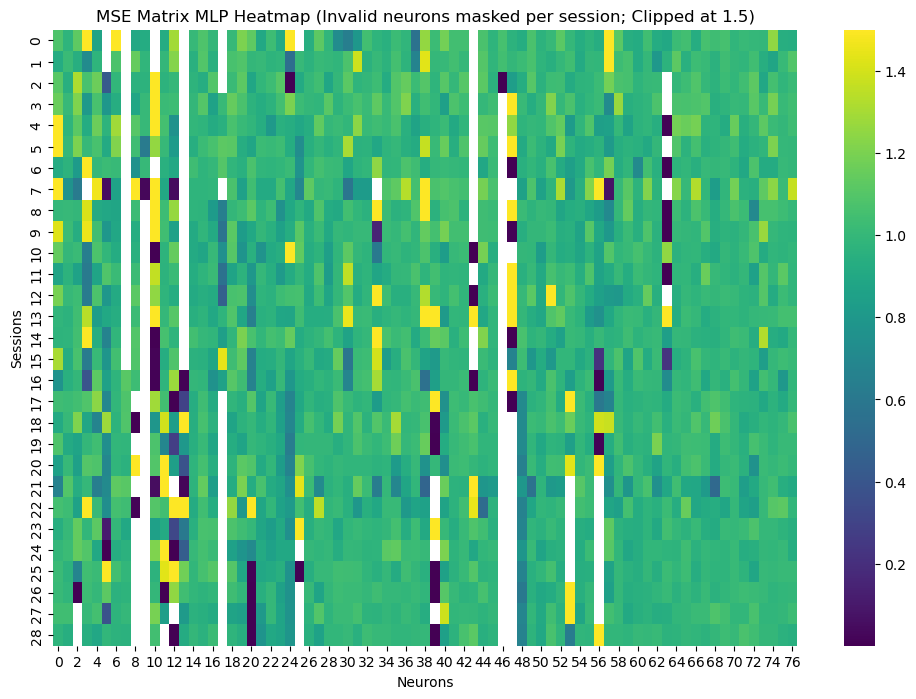

In [17]:
# Load the MSE matrix
mse_matrix = np.load(os.path.join(base, "mse_matrix.npy"))

mse_matrix_clipped = np.clip(mse_matrix, a_min=0, a_max=1.5)

# Create a mask for invalid neurons (where std == 1e-8) per session
num_sessions, num_neurons = mse_matrix_clipped.shape
mask = np.zeros((num_sessions, num_neurons), dtype=bool)
for i, session_id in enumerate(session_ids):
    label_stds = session_dataset_singles[session_id]["label_stds"]
    for j, std in enumerate(label_stds):
        if std == 1e-8:
            mask[i, j] = True

# Plot the heatmap with masked invalid cells
plt.figure(figsize=(12, 8))
sns.heatmap(mse_matrix_clipped, mask=mask, cmap='viridis', cbar=True)
plt.title('MSE Matrix MLP Heatmap (Invalid neurons masked per session; Clipped at 1.5)')
plt.xlabel('Neurons')
plt.ylabel('Sessions')
plt.show()

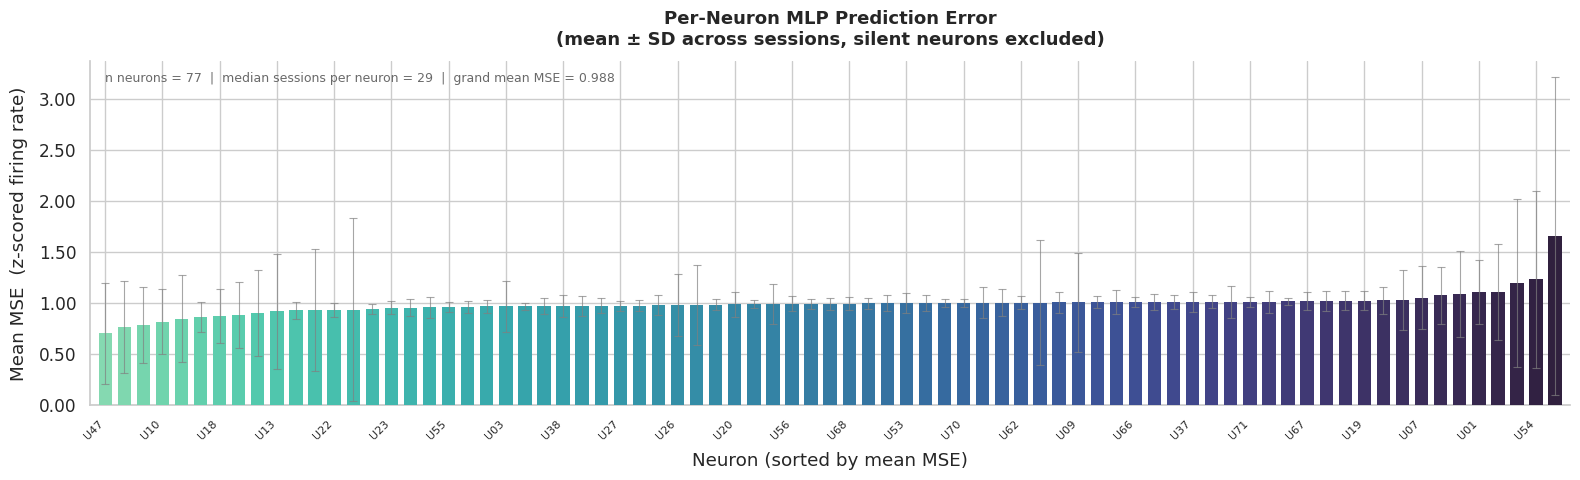

In [18]:


masked_mse = ma.array(mse_matrix, mask=mask)

# Per-neuron mean & std across sessions (ignoring masked entries)
neuron_mean = masked_mse.mean(axis=0).filled(np.nan)   # (num_neurons,)
neuron_std  = masked_mse.std(axis=0).filled(np.nan)

# Sort by mean for readability
order     = np.argsort(neuron_mean)
x         = np.arange(num_neurons)
labels    = [f"U{i+1:02d}" for i in order]
means_s   = neuron_mean[order]
stds_s    = neuron_std[order]

# ── style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette   = sns.color_palette("mako_r", as_cmap=True)
colors    = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.errorbar(x, means_s, yerr=stds_s,
            fmt="none", ecolor="gray", elinewidth=0.8,
            capsize=3, capthick=0.8, zorder=4, alpha=0.7)

# ── annotations ────────────────────────────────────────────────────────────
ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Neuron (sorted by mean MSE)", labelpad=8)
ax.set_ylabel("Mean MSE  (z-scored firing rate)", labelpad=8)
ax.set_title("Per-Neuron MLP Prediction Error\n"
             "(mean ± SD across sessions, silent neurons excluded)",
             fontsize=13, fontweight="bold", pad=12)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.spines[["top", "right"]].set_visible(False)

# colour-bar substitute: small inset text legend
valid_counts = (~mask).sum(axis=0)[order]
ax.annotate(
    f"n neurons = {num_neurons}  |  "
    f"median sessions per neuron = {int(np.median(valid_counts))}  |  "
    f"grand mean MSE = {np.nanmean(neuron_mean):.3f}",
    xy=(0.01, 0.97), xycoords="axes fraction",
    va="top", ha="left", fontsize=9, color="dimgray"
)

plt.tight_layout()
plt.show()


In [40]:
mse_matrix_lstm = np.zeros((num_sessions, num_neurons)) - 1  # initialize with -1 to distinguish from valid MSE values (which are >= 0)

In [ ]:
torch.cuda.empty_cache()

window_offset = 25

# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

num_neurons = session_dataset_singles[session_ids[0]]["labels"].shape[1]
num_sessions = len(session_ids)

input_size = len(action_enc_cols) + len(state_enc_cols)
hidden_size = 16
output_size = num_neurons
num_epochs = 100
learning_rate = 0.001
train_test_split = 0.8


for test_idx, test_session in enumerate(session_ids):
    session_data = session_dataset_singles[test_session]["data"]
    session_labels = session_dataset_singles[test_session]["labels"]
    session_label_stds = session_dataset_singles[test_session]["label_stds"]
    
    # Create sliding windows of size window_size
    def create_windows(data, labels, window_offset):
        data_windows = []
        label_windows = []
        for i in range(window_offset, len(data) - window_offset):
            data_windows.append(data[i - window_offset:i + window_offset + 1])
            label_windows.append(labels[i: i + 1])
            # print(data_windows[-1].shape, label_windows[-1].shape)
        return np.array(data_windows), np.array(label_windows)
    
    data_windows, label_windows = create_windows(session_data, session_labels, window_offset)
    print(data_windows.shape, label_windows.shape)
    
    # Split train/test
    n_samples = len(data_windows)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    split_idx = int(n_samples * train_test_split)
    
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    train_data = torch.tensor(data_windows[train_indices], dtype=torch.float32).to(device)
    train_labels = torch.tensor(label_windows[train_indices], dtype=torch.float32).to(device)
    test_data = torch.tensor(data_windows[test_indices], dtype=torch.float32).to(device)
    test_labels = label_windows[test_indices]
        
    for neuron_idx in range(num_neurons):

        if mse_matrix_lstm[test_idx, neuron_idx] > -0.5:
            print(f"Session {test_idx + 1}/{num_sessions}, Neuron {neuron_idx + 1}/{num_neurons} already computed, skipping...")
            continue
        
        # Train single LSTM model for all neurons
        model = LSTM(input_size, hidden_size, 1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        batch_size = 32
        num_batches = (len(train_data) + batch_size - 1) // batch_size
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0.0
            
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, len(train_data))
                
                batch_data = train_data[start_idx:end_idx]
                batch_labels = train_labels[start_idx:end_idx]
                
                optimizer.zero_grad()
                _, outputs = model(batch_data)
                # print(outputs.shape, batch_labels.shape)
                loss = criterion(outputs[:, -1, 0], batch_labels[:, 0, neuron_idx])
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
        
        # Test
        model.eval()
        with torch.no_grad():
            _, predictions = model(test_data)
            predictions = predictions.cpu().numpy()
        
        # Calculate MSE per neuron
        mse = mean_squared_error(test_labels[:, 0, neuron_idx], predictions[:, -1, 0])
        mse_matrix_lstm[test_idx, neuron_idx] = mse
        print(f"Session {test_idx + 1}/{num_sessions}, Neuron {neuron_idx + 1}/{num_neurons}, MSE: {mse:.4f} STD: {session_label_stds[neuron_idx]}")
        
        
        torch.cuda.empty_cache()

        # Clear GPU memory by deleting torch variables
        del model, optimizer, criterion
        del predictions
        torch.cuda.empty_cache()
    del train_data, train_labels, test_data, test_labels
    print(f"Session {test_idx + 1}/{num_sessions} - Training complete")


Using device: cuda
(22860, 51, 11) (22860, 1, 77)
Session 1/29, Neuron 1/77, MSE: 1.2183 STD: 6.274097400896827
Session 1/29, Neuron 2/77, MSE: 1.2630 STD: 3.5353091172308275
Session 1/29, Neuron 3/77, MSE: 1.2568 STD: 2.503710755857345
Session 1/29, Neuron 4/77, MSE: 1.0716 STD: 0.6394997193393676
Session 1/29, Neuron 5/77, MSE: 1.3860 STD: 3.751832519416257
Session 1/29, Neuron 6/77, MSE: 0.0000 STD: 1e-08
Session 1/29, Neuron 7/77, MSE: 0.8948 STD: 3.121883233536791
Session 1/29, Neuron 8/77, MSE: 0.0000 STD: 1e-08
Session 1/29, Neuron 9/77, MSE: 1.5561 STD: 2.6691510872169184
Session 1/29, Neuron 10/77, MSE: 1.1326 STD: 15.763235884757103
Session 1/29, Neuron 11/77, MSE: 0.0000 STD: 1e-08
Session 1/29, Neuron 12/77, MSE: 1.1936 STD: 11.25011422431629
Session 1/29, Neuron 13/77, MSE: 1.6713 STD: 1.8417968934403177
Session 1/29, Neuron 14/77, MSE: 0.0000 STD: 1e-08
Session 1/29, Neuron 15/77, MSE: 1.1131 STD: 38.859907183440725
Session 1/29, Neuron 16/77, MSE: 1.4054 STD: 5.984408300

In [ ]:
# save to disk
np.save(os.path.join(base, "mse_matrix_lstm.npy"), mse_matrix_lstm)

# optional human-readable version
np.savetxt(os.path.join(base, "mse_matrix_lstm.csv"), mse_matrix_lstm, delimiter=",")

In [ ]:

# Load the MSE matrix
mse_matrix_lstm = np.load(os.path.join(base, "mse_matrix_lstm.npy"))
mse_matrix_lstm_clipped = np.clip(mse_matrix_lstm, a_min=0, a_max=1.5)

# Create a mask for invalid neurons (where std == 1e-8) per session
num_sessions, num_neurons = mse_matrix_lstm_clipped.shape
mask = np.zeros((num_sessions, num_neurons), dtype=bool)
for i, session_id in enumerate(session_ids):
    label_stds = session_dataset_singles[session_id]["label_stds"]
    for j, std in enumerate(label_stds):
        if std == 1e-8:
            mask[i, j] = True

# Plot the heatmap with masked invalid cells
plt.figure(figsize=(12, 8))
sns.heatmap(mse_matrix_lstm_clipped, mask=mask, cmap='viridis', cbar=True)
plt.title('MSE Matrix LSTM Heatmap (Invalid neurons masked per session)')
plt.xlabel('Neurons')
plt.ylabel('Sessions')
plt.show()

In [ ]:


masked_mse = ma.array(mse_matrix_lstm, mask=mask)

# Per-neuron mean & std across sessions (ignoring masked entries)
neuron_mean = masked_mse.mean(axis=0).filled(np.nan)   # (num_neurons,)
neuron_std  = masked_mse.std(axis=0).filled(np.nan)

# Sort by mean for readability
order     = np.argsort(neuron_mean)
x         = np.arange(num_neurons)
labels    = [f"U{i+1:02d}" for i in order]
means_s   = neuron_mean[order]
stds_s    = neuron_std[order]

# ── style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette   = sns.color_palette("mako_r", as_cmap=True)
colors    = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.errorbar(x, means_s, yerr=stds_s,
            fmt="none", ecolor="gray", elinewidth=0.8,
            capsize=3, capthick=0.8, zorder=4, alpha=0.7)

# ── annotations ────────────────────────────────────────────────────────────
ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Neuron (sorted by mean MSE)", labelpad=8)
ax.set_ylabel("Mean MSE  (z-scored firing rate)", labelpad=8)
ax.set_title("Per-Neuron LSTM Prediction Error\n"
             "(mean ± SD across sessions, silent neurons excluded)",
             fontsize=13, fontweight="bold", pad=12)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.spines[["top", "right"]].set_visible(False)

# colour-bar substitute: small inset text legend
valid_counts = (~mask).sum(axis=0)[order]
ax.annotate(
    f"n neurons = {num_neurons}  |  "
    f"median sessions per neuron = {int(np.median(valid_counts))}  |  "
    f"grand mean MSE = {np.nanmean(neuron_mean):.3f}",
    xy=(0.01, 0.97), xycoords="axes fraction",
    va="top", ha="left", fontsize=9, color="dimgray"
)

plt.tight_layout()
plt.show()
